In [37]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import numpy as np

from main import NeuralNetMLP

In [39]:
X, y = fetch_openml("mnist_784", version=1, return_X_y=True)

X = X.values
y = y.astype(int).values

In [40]:
X.shape, y.shape

((70000, 784), (70000,))

In [41]:
# Приводим значения пикселей в MNIST к диапазону от -1 до 1
X = ((X / 255.) - .5) * 2

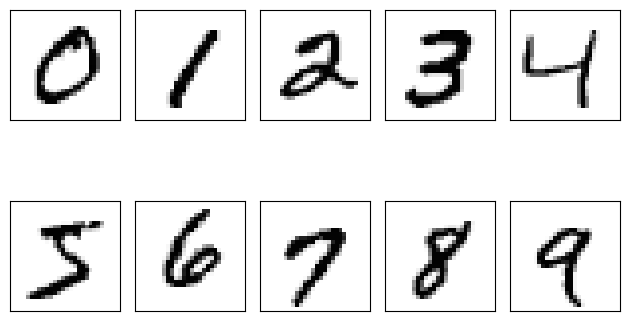

In [42]:
# Визуализируем цифры, как матрицы

fig, ax = plt.subplots(nrows=2, ncols=5, sharex=True, sharey=True)
ax = ax.flatten()
for i in range(10):
    img = X[y == i][0].reshape(28, 28)
    ax[i].imshow(img, cmap='Greys')

ax[0].set_xticks([])
ax[0].set_yticks([])
plt.tight_layout()
plt.show()

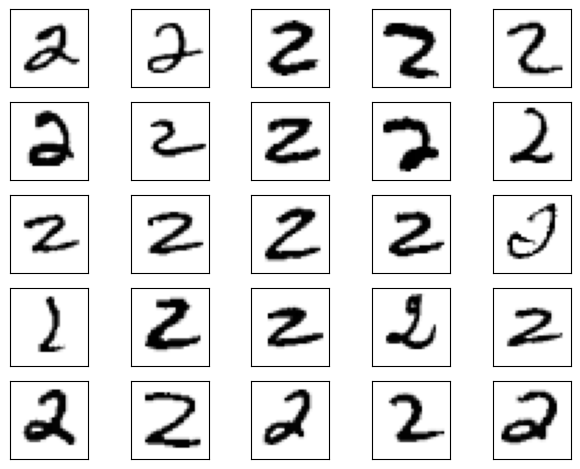

In [43]:
fig, ax = plt.subplots(nrows=5, ncols=5, sharex=True, sharey=True)
ax = ax.flatten()
for i in range(25):
    img = X[y == 2][i].reshape(28, 28)
    ax[i].imshow(img, cmap='Greys')

ax[0].set_xticks([])
ax[0].set_yticks([])
plt.tight_layout()
plt.show()

In [44]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=10000, random_state=123, stratify=y)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_temp, y_temp, test_size=5000, random_state=123, stratify=y_temp)


# optional to free up some memory by deleting non-used arrays:
del X_temp, y_temp, X, y

In [53]:
def sigmoid(z):
    """
        σ(x) = 1 / (1 + e^(-x))
    """
    return 1. / (1. + np.exp(-z))


def int_to_onehot(y, num_labels):
    """
        Для OvR(OvA)
    """
    ary = np.zeros((y.shape[0], num_labels))
    for i, val in enumerate(y):
        ary[i, val] = 1

    return ary

In [45]:
model = NeuralNetMLP(
    num_features=28*28,
    num_hidden=50,
    num_classes=10
)

In [46]:
num_epochs = 50
minibatch_size = 100

def minibatch_generator(X, y, minibatch_size):
    indices = np.arange(X.shape[0])
    np.random.shuffle(indices)

    for start_idx in range(0, indices.shape[0] - minibatch_size 
                           + 1, minibatch_size):
        batch_idx = indices[start_idx:start_idx + minibatch_size]
        
        yield X[batch_idx], y[batch_idx]

In [47]:
def mse_loss(targets, probas, num_labels=10):
    onehot_targets = int_to_onehot(targets, num_labels=num_labels)
    return np.mean((onehot_targets - probas)**2)


def accuracy(targets, predicted_labels):
    return np.mean(predicted_labels == targets) 

In [48]:
def compute_mse_and_acc(nnet, X, y, num_labels=10, minibatch_size=100):
    mse, correct_pred, num_examples = 0., 0, 0
    minibatch_gen = minibatch_generator(X, y, minibatch_size)
        
    for i, (features, targets) in enumerate(minibatch_gen):

        _, probas = nnet.forward(features)
        predicted_labels = np.argmax(probas, axis=1)
        
        onehot_targets = int_to_onehot(targets, num_labels=num_labels)
        loss = np.mean((onehot_targets - probas)**2)
        correct_pred += (predicted_labels == targets).sum()
        
        num_examples += targets.shape[0]
        mse += loss

    mse = mse/(i+1)
    acc = correct_pred/num_examples
    return mse, acc

In [49]:
def train(model, X_train, y_train, X_valid, y_valid, num_epochs,
          learning_rate=0.1):
    
    epoch_loss = []
    epoch_train_acc = []
    epoch_valid_acc = []
    
    for e in range(num_epochs):

        # iterate over minibatches
        minibatch_gen = minibatch_generator(
            X_train, y_train, minibatch_size)

        for X_train_mini, y_train_mini in minibatch_gen:
            
            #### Compute outputs ####
            a_h, a_out = model.forward(X_train_mini)

            #### Compute gradients ####
            d_loss__d_w_out, d_loss__d_b_out, d_loss__d_w_h, d_loss__d_b_h = \
                model.backward(X_train_mini, a_h, a_out, y_train_mini)

            #### Update weights ####
            model.weight_h -= learning_rate * d_loss__d_w_h
            model.bias_h -= learning_rate * d_loss__d_b_h
            model.weight_out -= learning_rate * d_loss__d_w_out
            model.bias_out -= learning_rate * d_loss__d_b_out
        
        #### Epoch Logging ####        
        train_mse, train_acc = compute_mse_and_acc(model, X_train, y_train)
        valid_mse, valid_acc = compute_mse_and_acc(model, X_valid, y_valid)
        train_acc, valid_acc = train_acc*100, valid_acc*100
        epoch_train_acc.append(train_acc)
        epoch_valid_acc.append(valid_acc)
        epoch_loss.append(train_mse)
        print(f'Epoch: {e+1:03d}/{num_epochs:03d} '
              f'| Train MSE: {train_mse:.2f} '
              f'| Train Acc: {train_acc:.2f}% '
              f'| Valid Acc: {valid_acc:.2f}%')

    return epoch_loss, epoch_train_acc, epoch_valid_acc

In [55]:
np.random.seed(123) # for the training set shuffling

epoch_loss, epoch_train_acc, epoch_valid_acc = train(
    model, X_train, y_train, X_valid, y_valid,
    num_epochs=50, learning_rate=0.1)

Epoch: 001/050 | Train MSE: 0.03 | Train Acc: 85.39% | Valid Acc: 84.96%
Epoch: 002/050 | Train MSE: 0.02 | Train Acc: 87.91% | Valid Acc: 87.58%
Epoch: 003/050 | Train MSE: 0.02 | Train Acc: 89.20% | Valid Acc: 89.06%
Epoch: 004/050 | Train MSE: 0.02 | Train Acc: 90.17% | Valid Acc: 89.94%
Epoch: 005/050 | Train MSE: 0.02 | Train Acc: 90.78% | Valid Acc: 90.52%
Epoch: 006/050 | Train MSE: 0.02 | Train Acc: 91.10% | Valid Acc: 90.92%
Epoch: 007/050 | Train MSE: 0.02 | Train Acc: 91.48% | Valid Acc: 91.04%
Epoch: 008/050 | Train MSE: 0.01 | Train Acc: 91.75% | Valid Acc: 91.44%
Epoch: 009/050 | Train MSE: 0.01 | Train Acc: 92.12% | Valid Acc: 91.78%
Epoch: 010/050 | Train MSE: 0.01 | Train Acc: 92.30% | Valid Acc: 92.10%
Epoch: 011/050 | Train MSE: 0.01 | Train Acc: 92.51% | Valid Acc: 92.28%
Epoch: 012/050 | Train MSE: 0.01 | Train Acc: 92.68% | Valid Acc: 92.34%
Epoch: 013/050 | Train MSE: 0.01 | Train Acc: 92.81% | Valid Acc: 92.58%
Epoch: 014/050 | Train MSE: 0.01 | Train Acc: 92.97

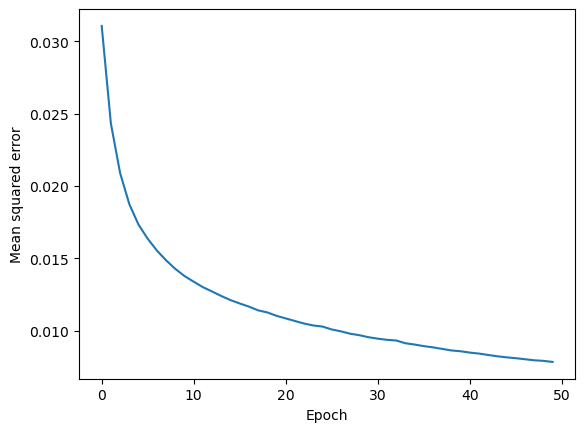

In [57]:
plt.plot(range(len(epoch_loss)), epoch_loss)
plt.ylabel('Mean squared error')
plt.xlabel('Epoch')
#plt.savefig('figures/11_07.png', dpi=300)
plt.show()

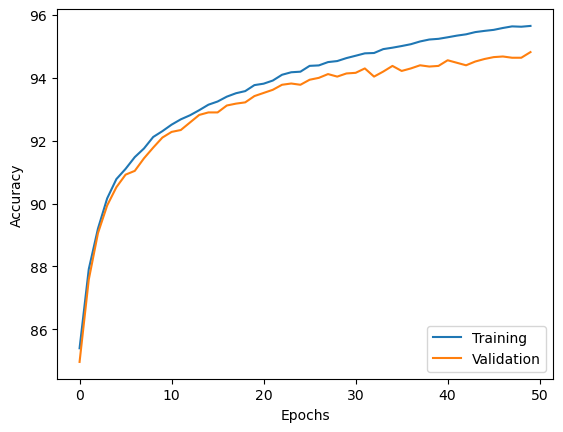

In [58]:
plt.plot(range(len(epoch_train_acc)), epoch_train_acc,
         label='Training')
plt.plot(range(len(epoch_valid_acc)), epoch_valid_acc,
         label='Validation')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(loc='lower right')
#plt.savefig('figures/11_08.png', dpi=300)
plt.show()

In [61]:
test_mse, test_acc = compute_mse_and_acc(model, X_test, y_test)
print(f'Test accuracy: {test_acc*100:.2f}%')

Test accuracy: 94.61%
